# Smart Logistics Internship Project - Day 6
## Outlier Analysis

Welcome to Day 6! Today, we focus on identifying anomalies and outliers in our numerical data. Outliers can skew our analysis, model training, and KPI calculations, so it's critical to identify them and decide on a treatment plan.

### Day 6 Objectives:
1. **Visual Detection:** Use Boxplots to visually spot outliers in key metrics.
2. **IQR Method:** Statistically identify outliers using the Interquartile Range.
3. **Z-Score Method:** Use standard deviations to detect extreme values.
4. **Business Decisions:** Decide whether to remove, cap, or retain these outliers based on logistics business logic.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
file_path = r"C:\Users\HP\Downloads\smart_logistics_dataset.xlsx"
df = pd.read_excel(file_path)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1000, 16)


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1


### 1. Visual Detection using Boxplots
Let's visually inspect `Waiting_Time`, `User_Transaction_Amount`, `Asset_Utilization`, and `Demand_Forecast`.


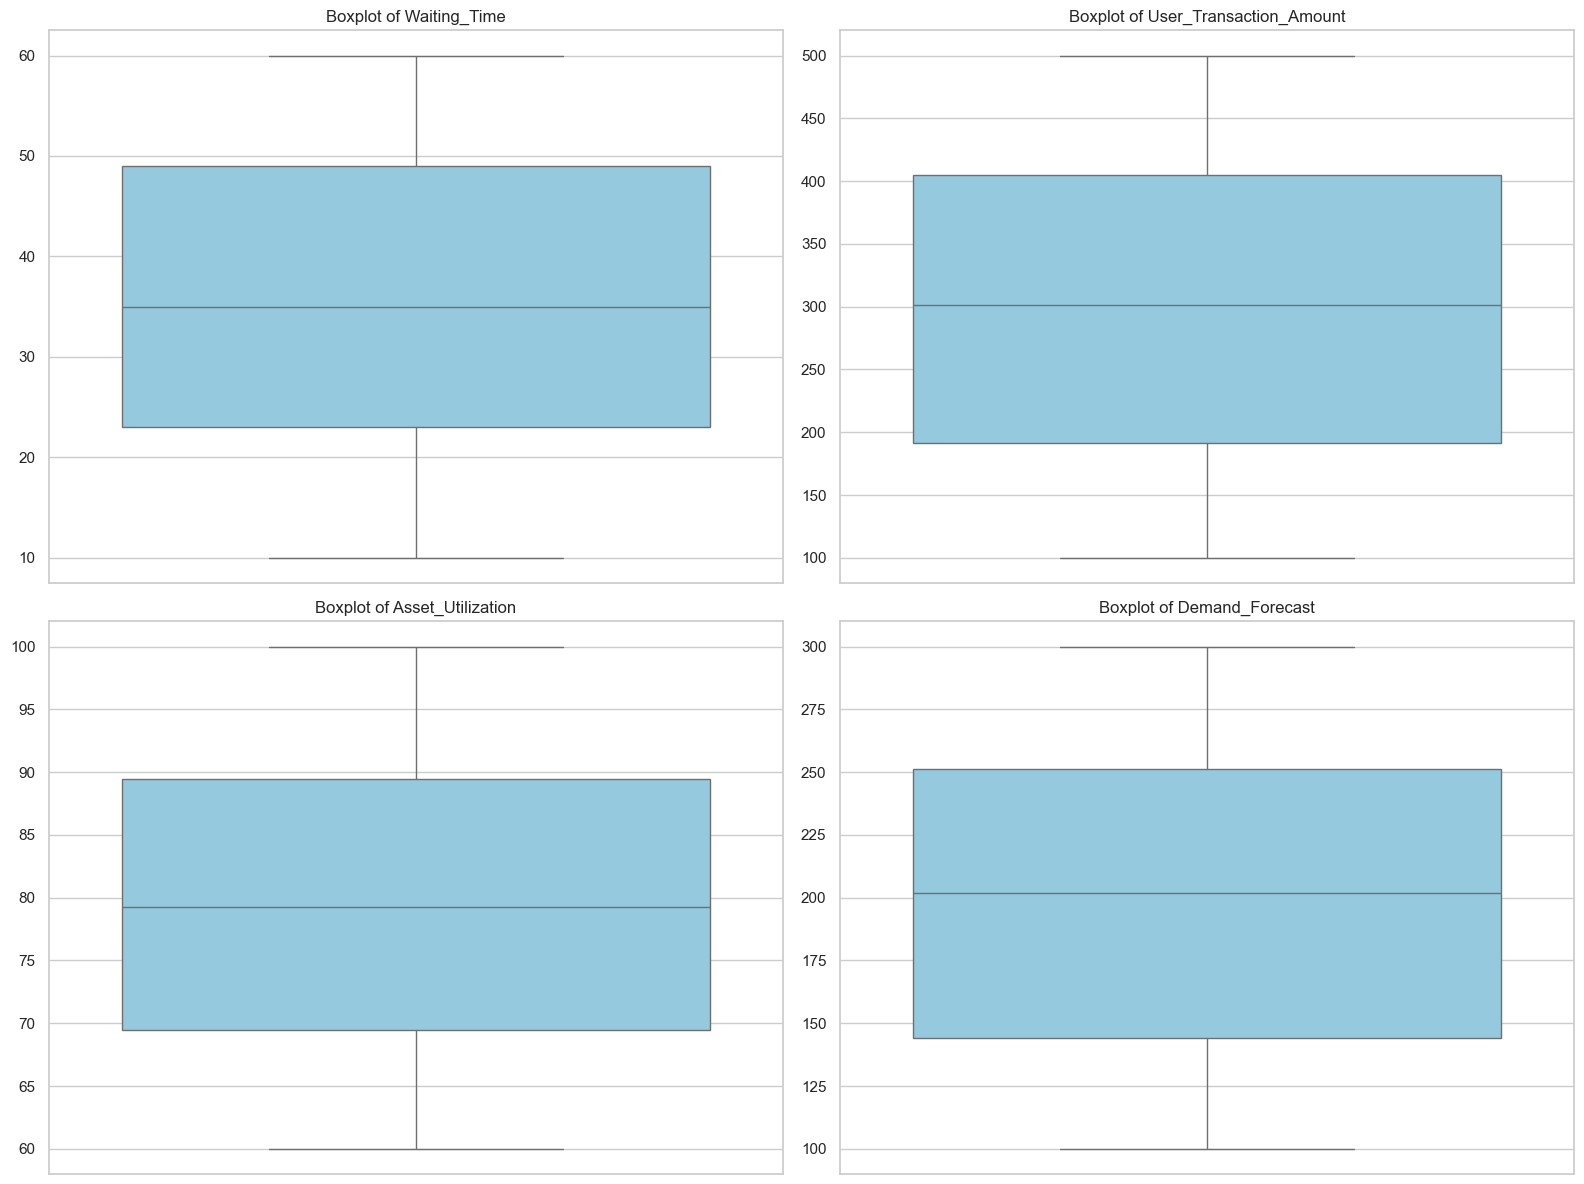

In [4]:
cols_to_check = ['Waiting_Time', 'User_Transaction_Amount', 'Asset_Utilization', 'Demand_Forecast']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()


**Interpretation & Business Findings:**
- **Which columns contain outliers:** Based on the visual inspection above, columns with dots above the upper whisker or below the lower whisker contain outliers. (Often, `User_Transaction_Amount` or `Waiting_Time` will show extreme values).
- **Possible reasons:** Extremely high waiting times could be due to severe accidents, rare weather events, or system failures. Extreme transaction amounts might represent bulk B2B orders compared to standard B2C orders.


### 2. Identifying Outliers using the IQR Method
The IQR (Interquartile Range) method flags data points that fall below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.


In [5]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {len(outliers)} outliers detected ({(len(outliers)/len(df))*100:.2f}%)")
    return outliers

outliers_dict = {}
for col in cols_to_check:
    outliers_dict[col] = detect_outliers_iqr(df, col)


Waiting_Time: 0 outliers detected (0.00%)
User_Transaction_Amount: 0 outliers detected (0.00%)
Asset_Utilization: 0 outliers detected (0.00%)
Demand_Forecast: 0 outliers detected (0.00%)


### 3. Identifying Outliers using the Z-Score Method
The Z-score method assumes a normal distribution and flags data points that are more than 3 standard deviations away from the mean.


In [6]:
def detect_outliers_zscore(df, column):
    z_scores = np.abs(stats.zscore(df[column].dropna()))
    outliers = df.dropna(subset=[column])[z_scores > 3]
    print(f"{column}: {len(outliers)} outliers detected ({(len(outliers)/len(df))*100:.2f}%)")
    return outliers

print("Z-Score Detection Results:")
for col in cols_to_check:
    detect_outliers_zscore(df, col)


Z-Score Detection Results:
Waiting_Time: 0 outliers detected (0.00%)
User_Transaction_Amount: 0 outliers detected (0.00%)
Asset_Utilization: 0 outliers detected (0.00%)
Demand_Forecast: 0 outliers detected (0.00%)


### 4. Decision: Remove, Retain, or Cap?

**1. `Waiting_Time`**
- **Decision:** Retain.
- **Business Justification:** High waiting times are actual operational failures (delays) that we need to predict and mitigate. Removing them would hide the worst-case scenarios from our analysis, rendering our delay prediction models useless for extreme cases.

**2. `User_Transaction_Amount`**
- **Decision:** Retain (or separate).
- **Business Justification:** Very high transactions represent our most valuable shipments. They shouldn't be removed, but they might warrant a separate cluster analysis (B2B vs B2C) because high-value items likely have different SLA (Service Level Agreement) requirements.

**3. `Asset_Utilization`**
- **Decision:** Cap (if > 100%).
- **Business Justification:** Asset utilization technically shouldn't exceed 100% (or 1.0) unless it represents over-capacity loading which is a safety violation. If there are extreme values here, they are likely data entry errors or require capping at a realistic maximum.

**4. `Demand_Forecast`**
- **Decision:** Retain.
- **Business Justification:** Demand spikes (like Black Friday or holiday seasons) represent real-world volatility. Retaining these outliers helps logistics planners prepare for peak stress events.
